# Step 3: Results & Real-Time Inference

This notebook implements the final stage of the pipeline:
1. **Load** the trained U-Net model checkpoint
2. **Single image inference** with side-by-side visualization
3. **Batch inference** on multiple test images
4. **Real-time video segmentation** – process a video and save the output
5. **Performance metrics** – measure inference speed (FPS)

This demonstrates that the lightweight U-Net achieves real-time performance suitable for robotic control.

In [13]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import cv2
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF


In [21]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Model checkpoint – trained in Notebook 02, or use original project's model
USE_PIPELINE_MODEL = True  # Set True if you trained in Notebook 02

if USE_PIPELINE_MODEL:
    CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "pipeline", "saved_models", "unet_trained.pth")
else:
    # Use original project's pre-trained model
    CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "UNet", "Saved Models", "working.pth")

# Test data paths
TEST_IMAGE_DIR = os.path.join(PROJECT_ROOT,"pipeline",  "dataset", "raw_images")
TEST_MASK_DIR = os.path.join(PROJECT_ROOT,"pipeline",  "dataset", "binary_masks")

# Video for real-time segmentation
VIDEO_PATH = os.path.join(PROJECT_ROOT, "Media", "video 1.mov")
OUTPUT_VIDEO_PATH = os.path.join(PROJECT_ROOT, "pipeline", "output_segmented.mp4")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Device: {device}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Video input: {VIDEO_PATH}")

Device: mps
Checkpoint: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/saved_models/unet_trained.pth
Video input: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/Media/video 1.mov


In [22]:
class UNet(nn.Module):
    """Lightweight U-Net for binary segmentation."""
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
            )

        self.down1 = conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bridge = conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_block2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_block1 = conv_block(128, 64)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        b = self.bridge(self.pool2(d2))
        u2 = self.up_block2(torch.cat([self.up2(b), d2], dim=1))
        u1 = self.up_block1(torch.cat([self.up1(u2), d1], dim=1))
        return torch.sigmoid(self.out(u1))

In [23]:
# Load trained model
model = UNet().to(device)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

print(f"Model loaded from: {CHECKPOINT_PATH}")
print(f"Model is in eval mode: {not model.training}")

Model loaded from: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/saved_models/unet_trained.pth
Model is in eval mode: True


In [24]:
class SegmentationTransform:
    """Transform for inference: resize + tensor conversion."""
    def __init__(self, size=(256, 256)):
        self.size = size
    
    def __call__(self, image, mask=None):
        image = TF.resize(image, self.size)
        image = TF.to_tensor(image)
        if mask is not None:
            mask = TF.resize(mask, self.size, interpolation=Image.NEAREST)
            mask = TF.to_tensor(mask)
        return image, mask


def predict_single_image(model, image_path, transform, device):
    """
    Run inference on a single image and return the prediction.
    
    Returns:
        original_image: PIL Image
        pred_mask: PIL Image (binary mask, resized to original)
        inference_time: float (seconds)
    """
    model.eval()
    
    # Load image
    image = Image.open(image_path).convert("RGB")
    original_size = image.size  # (width, height)
    
    # Preprocess
    image_tensor, _ = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Inference
    t0 = time.time()
    with torch.no_grad():
        output = model(image_tensor)
        pred_mask = (output > 0.5).float().squeeze().cpu()
    t1 = time.time()
    
    # Resize mask back to original size
    pred_mask_img = TF.to_pil_image(pred_mask)
    pred_mask_img = pred_mask_img.resize(original_size, resample=Image.NEAREST)
    
    return image, pred_mask_img, t1 - t0


def dice_score(pred, target, epsilon=1e-6):
    """Compute Dice score between two binary arrays."""
    pred = np.array(pred).astype(float) / 255.0
    target = np.array(target).astype(float) / 255.0
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2.0 * intersection + epsilon) / (union + epsilon)

transform = SegmentationTransform(size=(256, 256))

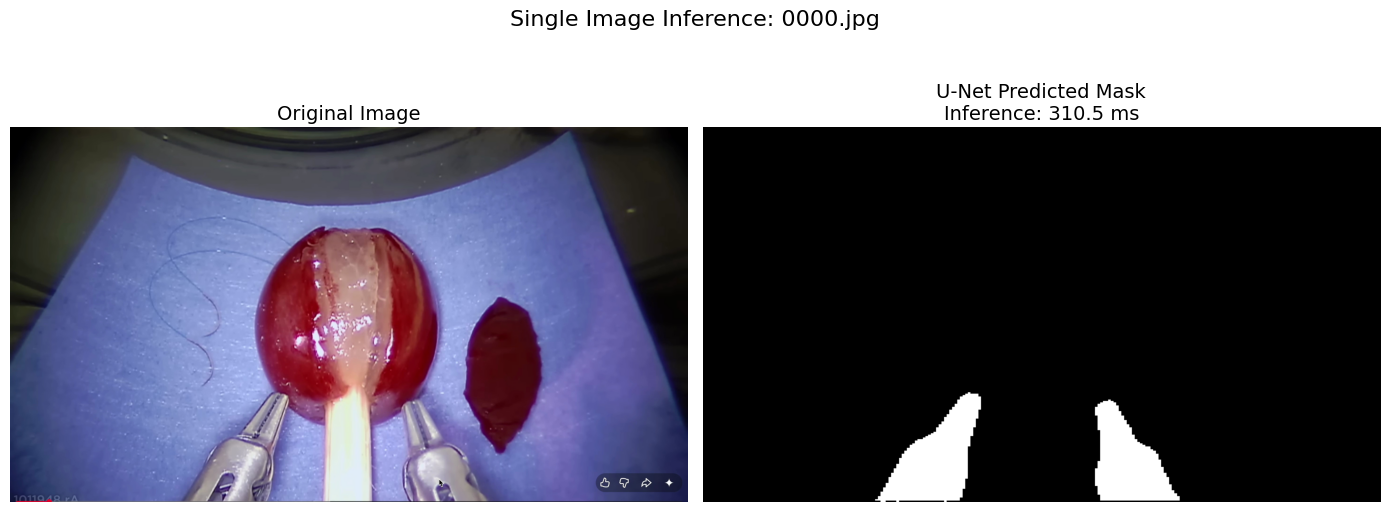

In [25]:
# Pick a test image
test_images = sorted([f for f in os.listdir(TEST_IMAGE_DIR) if f.endswith('.jpg')])
sample_image_name = test_images[0]
sample_image_path = os.path.join(TEST_IMAGE_DIR, sample_image_name)

# Run inference
original, pred_mask, inf_time = predict_single_image(model, sample_image_path, transform, device)

# Display
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(pred_mask, cmap='gray')
axes[1].set_title(f"U-Net Predicted Mask\nInference: {inf_time*1000:.1f} ms", fontsize=14)
axes[1].axis('off')

plt.suptitle(f"Single Image Inference: {sample_image_name}", fontsize=16)
plt.tight_layout()
plt.show()

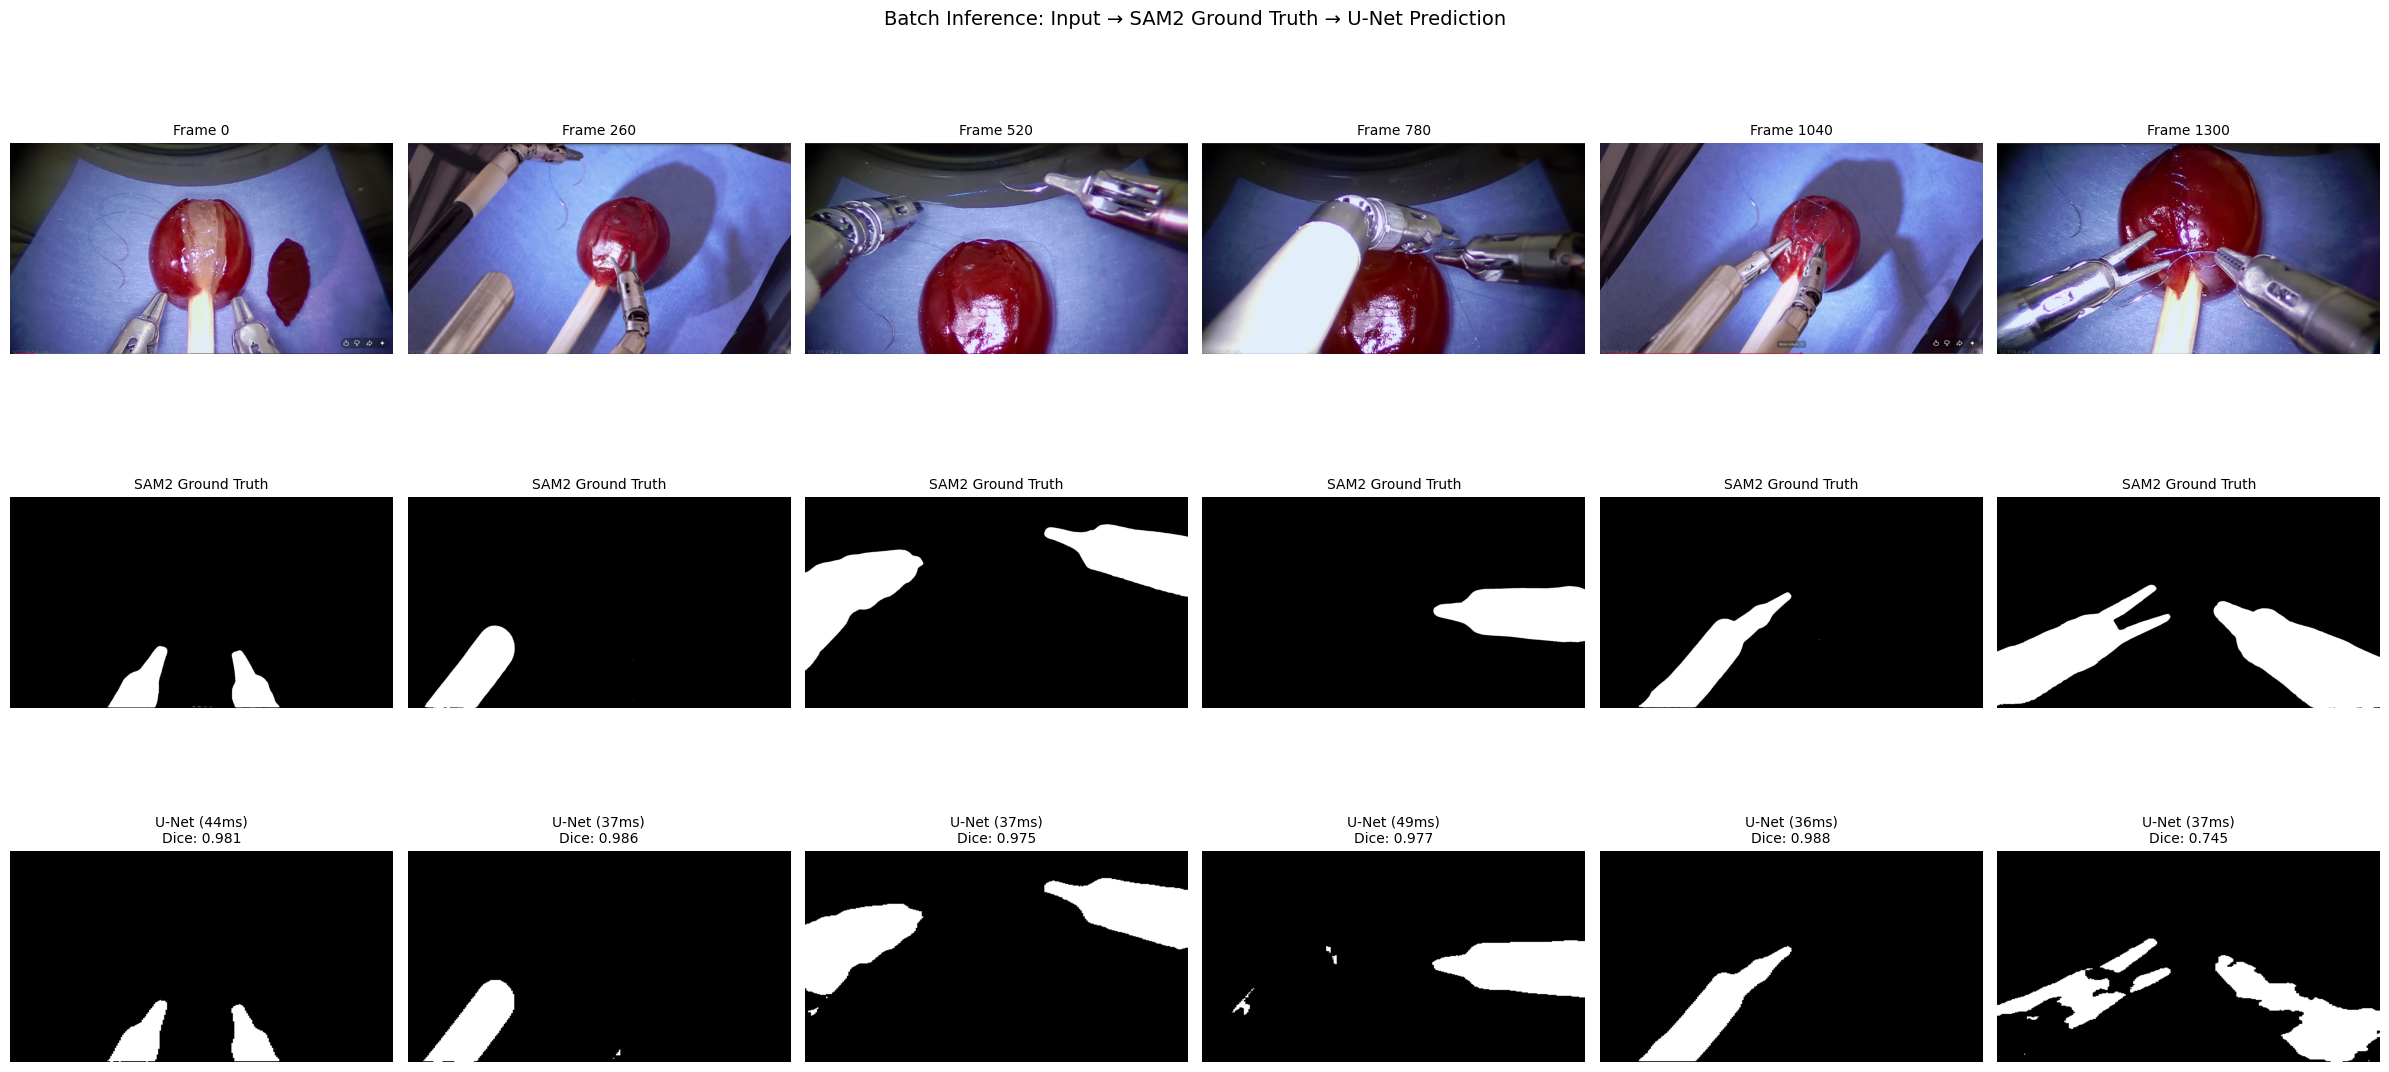


Average Dice Score across 6 samples: 0.9419


In [26]:
# Select evenly-spaced test samples
n_samples = 6
step = max(1, len(test_images) // n_samples)
sample_indices = list(range(0, len(test_images), step))[:n_samples]

fig, axes = plt.subplots(3, n_samples, figsize=(4 * n_samples, 12))
dice_scores = []

for col, idx in enumerate(sample_indices):
    img_name = test_images[idx]
    img_path = os.path.join(TEST_IMAGE_DIR, img_name)
    mask_path = os.path.join(TEST_MASK_DIR, img_name)
    
    # Run inference
    original, pred_mask, inf_time = predict_single_image(model, img_path, transform, device)
    
    # Row 0: Original image
    axes[0, col].imshow(original)
    axes[0, col].set_title(f"Frame {idx}", fontsize=10)
    axes[0, col].axis('off')
    
    # Row 1: Ground truth mask (SAM2)
    if os.path.exists(mask_path):
        gt_mask = Image.open(mask_path).convert('L')
        axes[1, col].imshow(gt_mask, cmap='gray')
        
        # Compute Dice
        d = dice_score(pred_mask, gt_mask)
        dice_scores.append(d)
    else:
        axes[1, col].text(0.5, 0.5, 'N/A', ha='center')
        d = None
    axes[1, col].set_title("SAM2 Ground Truth", fontsize=10)
    axes[1, col].axis('off')
    
    # Row 2: U-Net prediction
    axes[2, col].imshow(pred_mask, cmap='gray')
    title = f"U-Net ({inf_time*1000:.0f}ms)"
    if d is not None:
        title += f"\nDice: {d:.3f}"
    axes[2, col].set_title(title, fontsize=10)
    axes[2, col].axis('off')

# Row labels
axes[0, 0].set_ylabel("Input", fontsize=12)
axes[1, 0].set_ylabel("SAM2 (GT)", fontsize=12)
axes[2, 0].set_ylabel("U-Net (Pred)", fontsize=12)

plt.suptitle('Batch Inference: Input → SAM2 Ground Truth → U-Net Prediction', fontsize=14)
plt.tight_layout()
plt.show()

if dice_scores:
    print(f"\nAverage Dice Score across {len(dice_scores)} samples: {np.mean(dice_scores):.4f}")

## Real-Time Video Segmentation


In [27]:
def preprocess_frame(frame, transform):
    """Convert an OpenCV BGR frame to a model-ready tensor."""
    image_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).convert("RGB")
    dummy_mask = Image.new("L", image_pil.size)
    image_tensor, _ = transform(image_pil, dummy_mask)
    return image_tensor.unsqueeze(0)


def postprocess_mask(output, original_shape):
    """Convert model output to a colored mask matching original frame size."""
    pred_mask = (output > 0.5).float().squeeze().cpu().numpy()
    resized_mask = cv2.resize(pred_mask, original_shape, interpolation=cv2.INTER_NEAREST)
    mask_colored = cv2.cvtColor((resized_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    return mask_colored

In [28]:
# Open input video
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Failed to open video: {VIDEO_PATH}")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Input video: {frame_width}x{frame_height} @ {fps} FPS, {total_frames} frames")

# Setup output video writer (side-by-side: raw | mask)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (frame_width * 2, frame_height))

# Inference transform
inf_transform = SegmentationTransform(size=(256, 256))

# Process all frames
frame_times = []
frame_num = 0

print(f"Processing video...")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Preprocess
    input_tensor = preprocess_frame(frame, inf_transform).to(device)
    
    # Inference
    t0 = time.time()
    with torch.no_grad():
        output = model(input_tensor)
    t1 = time.time()
    
    frame_times.append(t1 - t0)
    
    # Postprocess
    mask_colored = postprocess_mask(output, (frame_width, frame_height))
    
    # Create side-by-side frame
    combined = np.hstack((frame, mask_colored))
    out.write(combined)
    
    frame_num += 1
    if frame_num % 50 == 0:
        print(f"  Frame {frame_num}/{total_frames} "
              f"({frame_times[-1]*1000:.1f} ms/frame)")

cap.release()
out.release()

print(f"\nProcessed {frame_num} frames")
print(f"Output saved to: {OUTPUT_VIDEO_PATH}")

Input video: 2880x1592 @ 59 FPS, 4680 frames
Processing video...
  Frame 50/4680 (2.2 ms/frame)
  Frame 100/4680 (2.1 ms/frame)
  Frame 150/4680 (5.4 ms/frame)
  Frame 200/4680 (2.2 ms/frame)
  Frame 250/4680 (2.1 ms/frame)
  Frame 300/4680 (4.7 ms/frame)
  Frame 350/4680 (2.0 ms/frame)
  Frame 400/4680 (2.1 ms/frame)
  Frame 450/4680 (2.3 ms/frame)
  Frame 500/4680 (2.2 ms/frame)
  Frame 550/4680 (3.0 ms/frame)
  Frame 600/4680 (2.5 ms/frame)
  Frame 650/4680 (2.3 ms/frame)
  Frame 700/4680 (2.1 ms/frame)
  Frame 750/4680 (2.4 ms/frame)
  Frame 800/4680 (2.3 ms/frame)
  Frame 850/4680 (2.3 ms/frame)
  Frame 900/4680 (2.2 ms/frame)
  Frame 950/4680 (2.3 ms/frame)
  Frame 1000/4680 (2.3 ms/frame)
  Frame 1050/4680 (2.4 ms/frame)
  Frame 1100/4680 (2.4 ms/frame)
  Frame 1150/4680 (2.4 ms/frame)
  Frame 1200/4680 (2.3 ms/frame)
  Frame 1250/4680 (2.5 ms/frame)
  Frame 1300/4680 (2.2 ms/frame)
  Frame 1350/4680 (2.3 ms/frame)
  Frame 1400/4680 (2.5 ms/frame)
  Frame 1450/4680 (2.3 ms/frame

## Performance Metrics

In [29]:
frame_times_ms = np.array(frame_times) * 1000  # Convert to milliseconds
fps_values = 1.0 / np.array(frame_times)

print("=" * 50)
print("INFERENCE PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Device: {device}")
print(f"Total frames processed: {len(frame_times)}")
print(f"")
print(f"Inference Time per Frame:")
print(f"  Mean:   {np.mean(frame_times_ms):.2f} ms")
print(f"  Median: {np.median(frame_times_ms):.2f} ms")
print(f"  Min:    {np.min(frame_times_ms):.2f} ms")
print(f"  Max:    {np.max(frame_times_ms):.2f} ms")
print(f"  Std:    {np.std(frame_times_ms):.2f} ms")
print(f"")
print(f"Frames Per Second (FPS):")
print(f"  Mean:   {np.mean(fps_values):.1f} FPS")
print(f"  Median: {np.median(fps_values):.1f} FPS")
print(f"")
real_time = np.mean(fps_values) >= 30
print(f"Real-time capable (≥30 FPS): {'YES' if real_time else 'NO (try GPU for real-time)'}")
print("=" * 50)

INFERENCE PERFORMANCE SUMMARY
Device: mps
Total frames processed: 4678

Inference Time per Frame:
  Mean:   2.52 ms
  Median: 2.49 ms
  Min:    1.86 ms
  Max:    32.75 ms
  Std:    0.70 ms

Frames Per Second (FPS):
  Mean:   404.6 FPS
  Median: 402.1 FPS

Real-time capable (≥30 FPS): YES


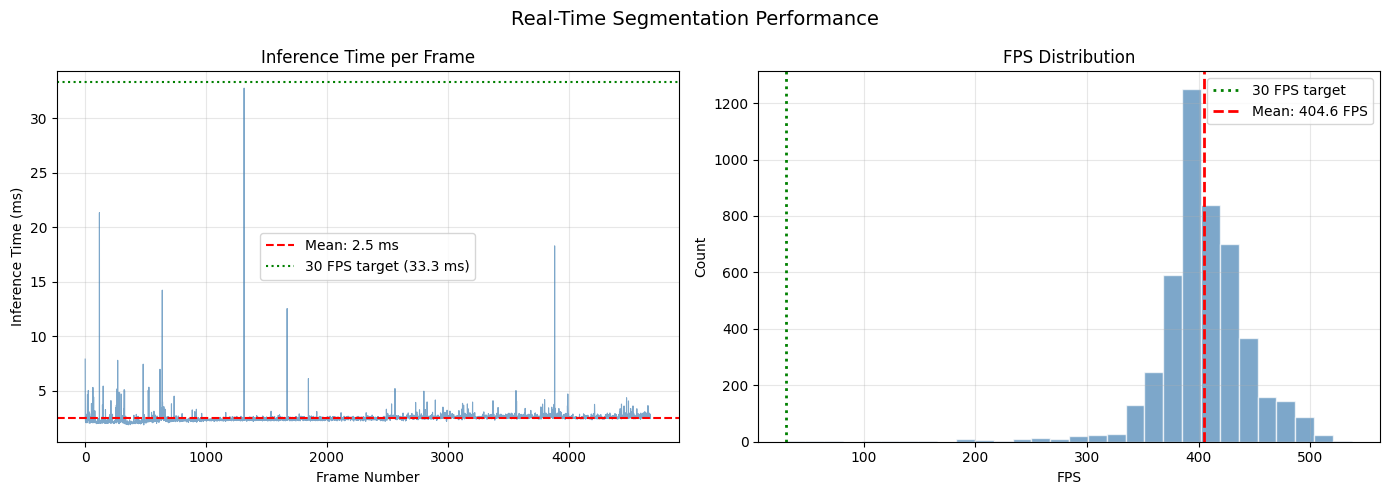

In [30]:
# Plot inference time distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Inference time per frame
ax1.plot(frame_times_ms, color='steelblue', alpha=0.7, linewidth=0.8)
ax1.axhline(y=np.mean(frame_times_ms), color='red', linestyle='--', 
            label=f'Mean: {np.mean(frame_times_ms):.1f} ms')
ax1.axhline(y=33.3, color='green', linestyle=':', 
            label='30 FPS target (33.3 ms)')
ax1.set_xlabel('Frame Number')
ax1.set_ylabel('Inference Time (ms)')
ax1.set_title('Inference Time per Frame')
ax1.legend()
ax1.grid(True, alpha=0.3)

# FPS histogram
ax2.hist(fps_values, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=30, color='green', linestyle=':', linewidth=2, label='30 FPS target')
ax2.axvline(x=np.mean(fps_values), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(fps_values):.1f} FPS')
ax2.set_xlabel('FPS')
ax2.set_ylabel('Count')
ax2.set_title('FPS Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Real-Time Segmentation Performance', fontsize=14)
plt.tight_layout()
plt.show()

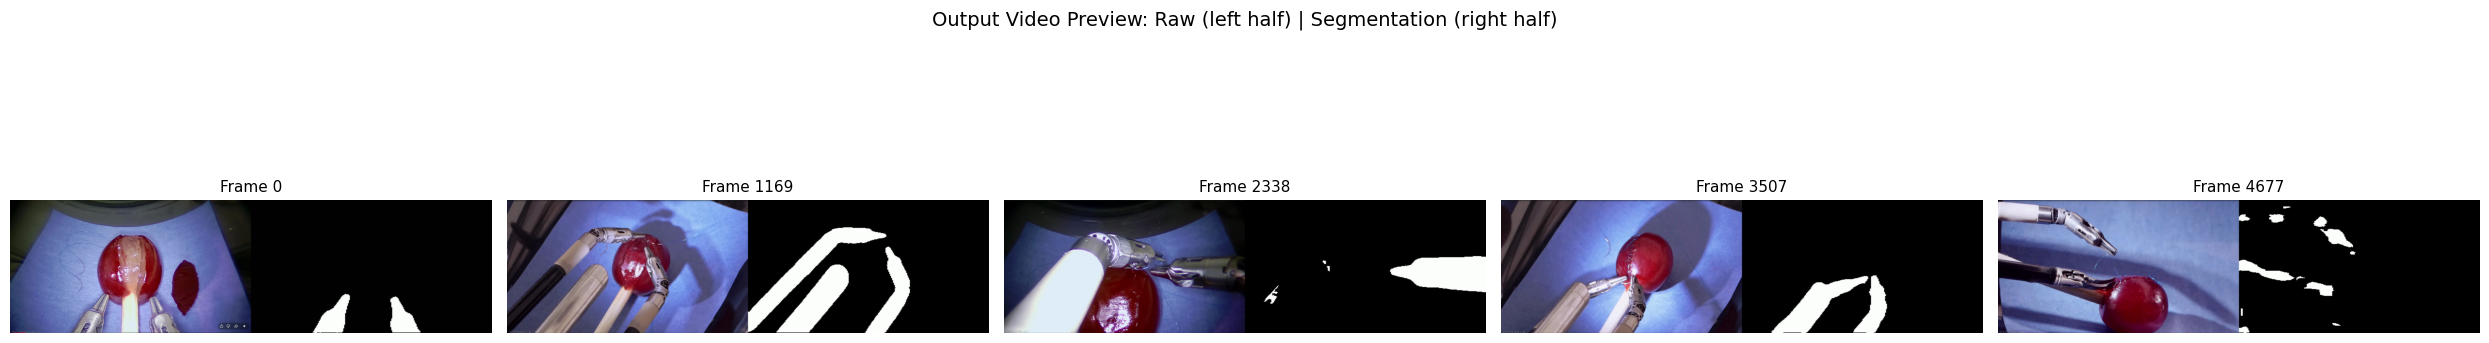


Full output video saved at: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/output_segmented.mp4
Open this file in any video player to see the complete result!


In [31]:
# Read and display sample frames from the output video
cap_out = cv2.VideoCapture(OUTPUT_VIDEO_PATH)
total_out = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))

# Sample 5 evenly-spaced frames
sample_positions = np.linspace(0, total_out - 1, 5, dtype=int)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, pos in enumerate(sample_positions):
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, pos)
    ret, frame = cap_out.read()
    if ret:
        # Convert BGR to RGB for display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {pos}", fontsize=11)
    axes[i].axis('off')

cap_out.release()

plt.suptitle(f'Output Video Preview: Raw (left half) | Segmentation (right half)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFull output video saved at: {OUTPUT_VIDEO_PATH}")
print(f"Open this file in any video player to see the complete result!")